In [1]:
import json
import os
import sys
import keras
from keras import layers
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix



DATA_DIR = r"C:\Users\lenovo\Documents\Fable\Aditya\plantvillage dataset\color"
IMG_SIZE = (224, 224)
BATCH_SIZE= 32
EPOCHS = 3
N_EXPLAIN = 3
MODEL_NAME = "efficientnet"

keras.utils.set_random_seed(42)

In [2]:
common = dict(validation_split=0.2, seed=42, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int")
train_ds = keras.utils.image_dataset_from_directory(DATA_DIR, subset="training", **common)
val_ds = keras.utils.image_dataset_from_directory(DATA_DIR, subset="validation", **common)
class_names = train_ds.class_names
train_ds = train_ds.prefetch(2)
val_ds = val_ds.prefetch(2)
print(len(class_names), "classes")

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
38 classes


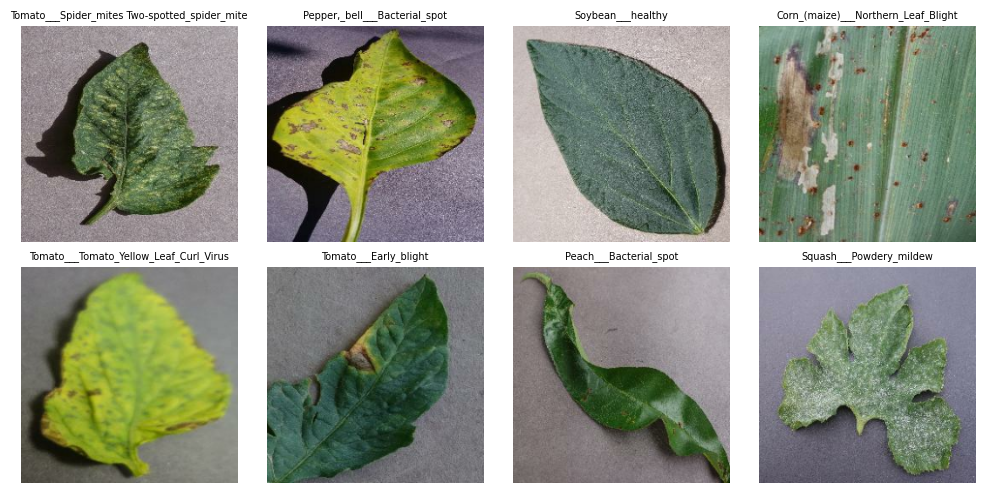

In [3]:
images, labels = next(iter(val_ds))

plt.figure(figsize=(10,5))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]],fontsize=7)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
BASES = {
    "efficientnet": keras.applications.EfficientNetB0,
    "resnet": keras.applications.ResNet50V2,
}

def build_model(name, num_classes):
    augment = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ], name="augmentation")

    base = BASES[name](include_top=False, weights="imagenet", pooling="avg")
    base.trainable=False

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x=augment(inputs)

    if name=="resnet":
        x = layers.Rescaling(1 / 127.5, offset=-1)(x)
    x=base(x)
    x=layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)


    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                                              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

model = build_model(MODEL_NAME, len(class_names))
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ augmentation (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 1280)                │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 38)                  │          48,678 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,098,249 (15.63 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [5]:
model_path = f"{MODEL_NAME}.keras"
if os.path.exists(model_path):
    print(f"Found {model_path} - loading instead of retraining.")
    model = keras.models.load_model(model_path)
else:
    model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)
    model.save(model_path)
    print(f"Saved {model_path}")

Found efficientnet.keras - loading instead of retraining.


In [6]:
y_true, y_pred = [], []
for batch_images, batch_labels in val_ds:
    probs = model.predict(batch_images, verbose=0)
    y_true.extend(batch_labels.numpy())
    y_pred.extend(probs.argmax(axis=1))
print(classification_report(y_true, y_pred, target_names=class_names))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.95      0.89      0.92       126
                                 Apple___Black_rot       1.00      0.99      1.00       132
                          Apple___Cedar_apple_rust       1.00      0.95      0.97        55
                                   Apple___healthy       0.94      0.98      0.96       329
                               Blueberry___healthy       0.98      1.00      0.99       295
          Cherry_(including_sour)___Powdery_mildew       1.00      0.98      0.99       232
                 Cherry_(including_sour)___healthy       1.00      0.98      0.99       167
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.83      0.95      0.89       108
                       Corn_(maize)___Common_rust_       0.99      1.00      0.99       219
               Corn_(maize)___Northern_Leaf_Blight       0.97      0.89      0.

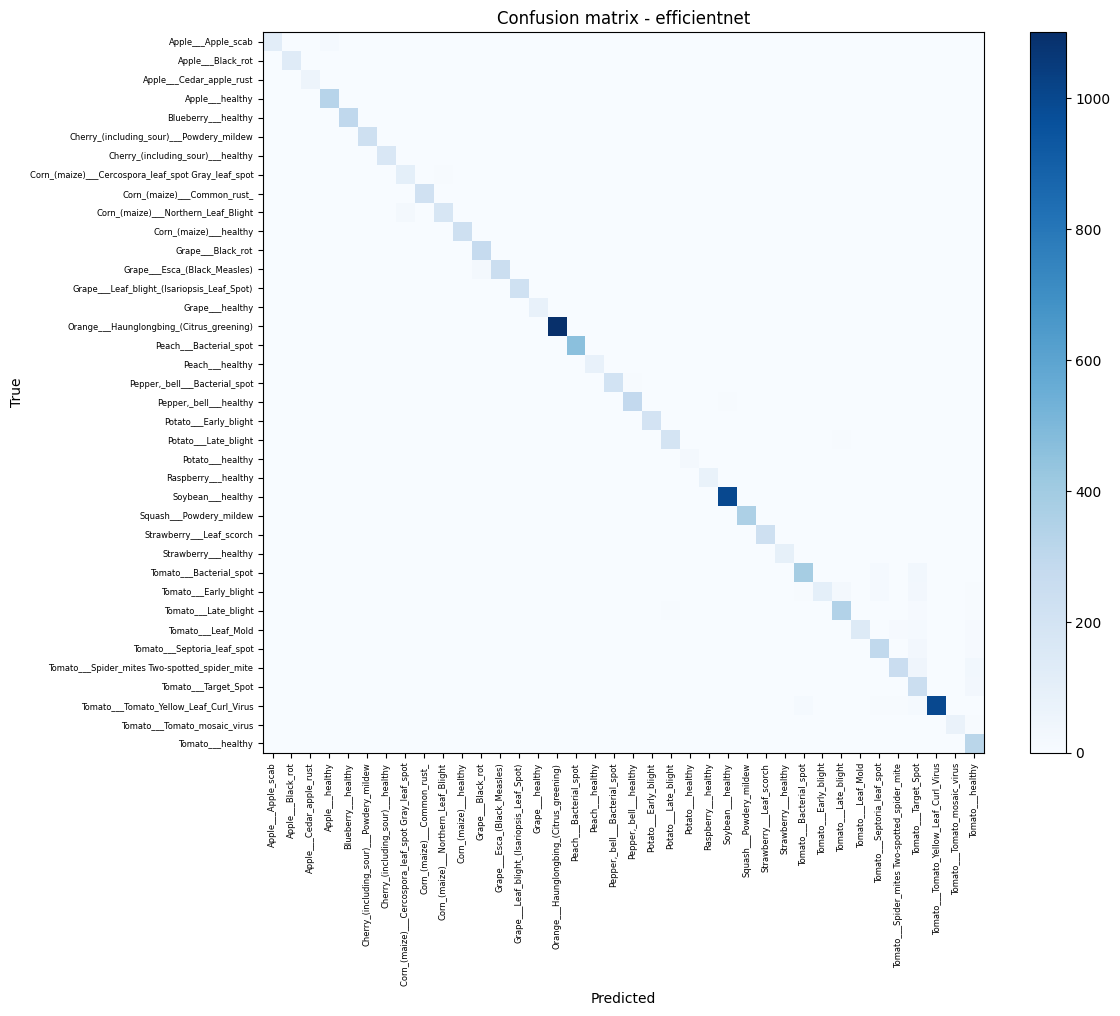

In [7]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=90, fontsize=6)
plt.yticks(ticks, class_names, fontsize=6)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion matrix - {MODEL_NAME}")
plt.tight_layout()
plt.savefig(f"confusion_matrix_{MODEL_NAME}.png", dpi=150)
plt.show()

In [8]:
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries

In [12]:
def predict(imgs):
    """Class probabilities for a batch of 0-255 RGB images."""
    return model.predict(np.asarray(imgs, dtype=np.float32), verbose=0)

# A few validation images to explain.
images, labels = next(iter(val_ds))
images = images.numpy()[:N_EXPLAIN]
labels = labels.numpy()[:N_EXPLAIN]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  33%|████████████████████▋                                         | 1/3 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████████████████████████████████████████████████| 3/3 [00:18<00:00,  3.29s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [00:24,  8.30s/it]                                                                   


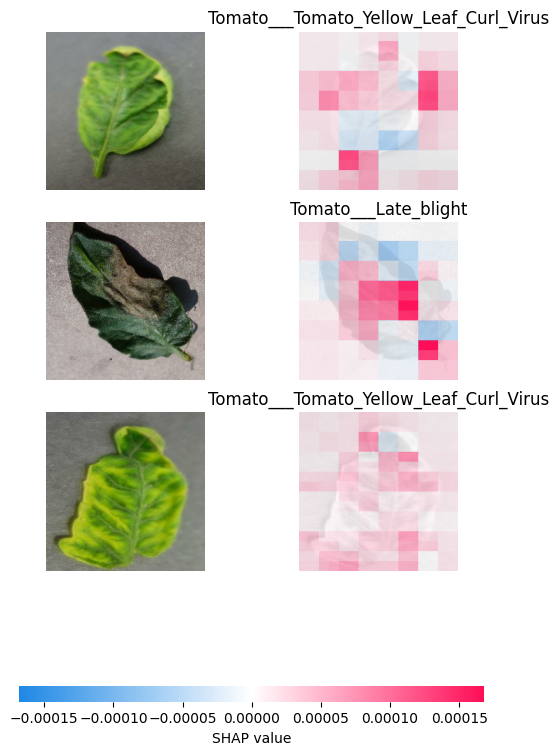

In [13]:
# SHAP - takes a few minutes on CPU.
preds = predict(images).argmax(axis=1)

masker = shap.maskers.Image("blur(128,128)", images[0].shape)
explainer = shap.Explainer(predict, masker, output_names=class_names)
sv = explainer(images, max_evals=500, batch_size=32,
               outputs=shap.Explanation.argsort.flip[:1])  # top predicted class

shap_values = [sv.values[..., 0]]                          # each image's top class
plot_labels = np.array([[class_names[i]] for i in preds])  # one label per image
shap.image_plot(shap_values, sv.data / 255.0, plot_labels, show=False)
plt.savefig(f"shap_{MODEL_NAME}.png", dpi=150, bbox_inches="tight")
plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

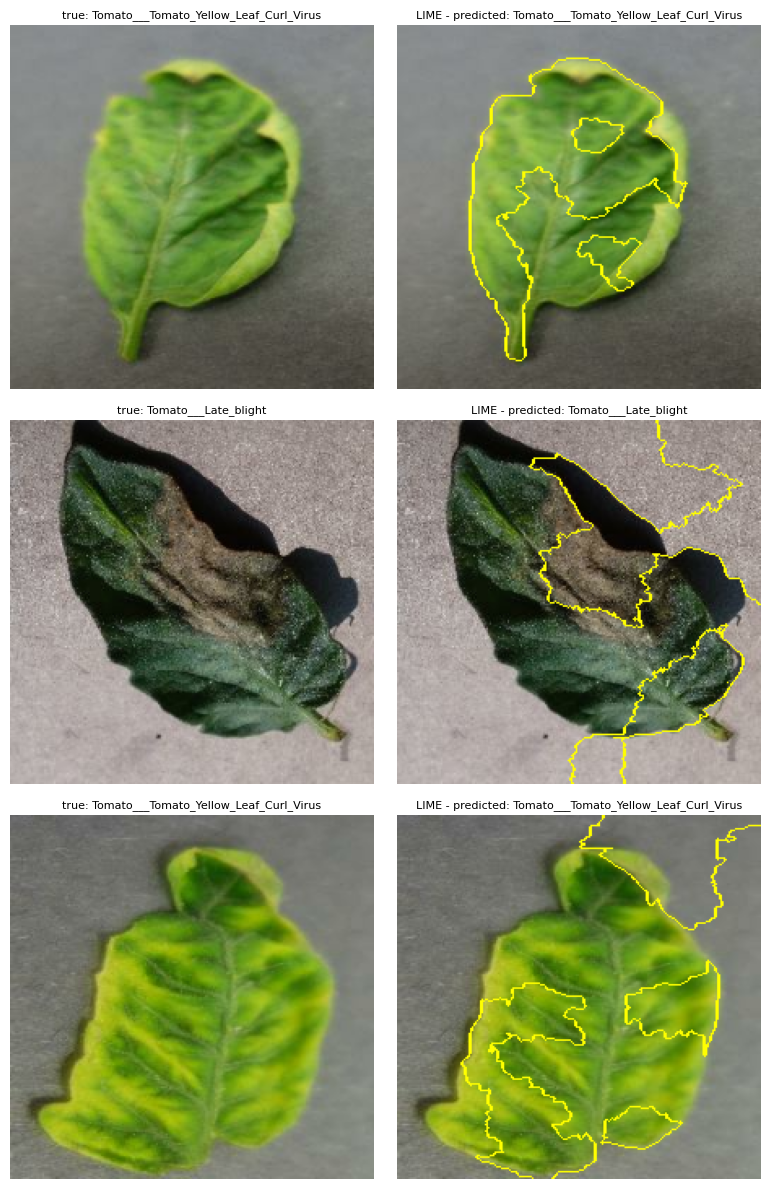

In [14]:
lime_explainer = lime_image.LimeImageExplainer(random_state=42)
fig, axes = plt.subplots(N_EXPLAIN, 2, figsize=(8, 4 * N_EXPLAIN))
for i, img in enumerate(images):
    exp = lime_explainer.explain_instance(img / 255.0, lambda x: predict(np.asarray(x) * 255.0),
                                          top_labels=1, num_samples=1000)
    top = exp.top_labels[0]
    temp, mask = exp.get_image_and_mask(top, positive_only=True,
                                        num_features=8, hide_rest=False)
    axes[i, 0].imshow(img.astype(np.uint8))
    axes[i, 0].set_title(f"true: {class_names[labels[i]]}", fontsize=8)
    axes[i, 1].imshow(mark_boundaries(temp, mask))
    axes[i, 1].set_title(f"LIME - predicted: {class_names[top]}", fontsize=8)
    for ax in axes[i]:
        ax.axis("off")
plt.tight_layout()
plt.savefig(f"lime_{MODEL_NAME}.png", dpi=150, bbox_inches="tight")
plt.show()